Hemos aprendido que el escalado es un problema común y crítico tanto en los LLMs como en el aprendizaje profundo en general. Las normalizaciones frecuentes representan una estrategia clave para mitigar estas dificultades numéricas, pero no son la única: la **inicialización de pesos** es otra técnica fundamental. En principio, todos los parámetros comienzan con valores aleatorios que luego se ajustan progresivamente mediante el descenso de gradiente; sin embargo, la distribución con la que se generan esos valores iniciales tiene un impacto determinante en la estabilidad y velocidad de convergencia.

En teoría, la escala inicial no debería importar demasiado: si las ponderaciones comienzan con valores excesivamente grandes, cabría esperar que el gradiente las reduzca de forma natural hasta alcanzar un rendimiento óptimo. Aunque esto puede funcionar en redes relativamente pequeñas, en arquitecturas masivas la situación cambia por completo. Con cientos de capas y sucesivas multiplicaciones matriciales, la propagación hacia adelante y hacia atrás se vuelve extremadamente propensa a explosiones o desvanecimientos numéricos. En modelos de esa escala, cualquier intervención que garantice estabilidad desde el inicio —como una inicialización adecuada que preserve la varianza— resulta decisiva para que el entrenamiento pueda converger con éxito.

En realidad es un principio bastante directo: se necesitan pesos aleatorios cuyos valores numéricos sean reducidos para evitar que la multiplicación de matrices infle la varianza. En la práctica, se utilizan tres métodos clásicos de inicialización:

1. **Inicialización gaussiana escalada ($\mathcal{N}(0, \sigma^2)$ con $\sigma \ll 1$):** Se muestrean valores de una distribución normal centrada en cero, multiplicada por una desviación estándar pequeña (por ejemplo, $\sigma = 0.02$, común en arquitecturas como GPT-2).
2. **Inicialización Xavier / Glorot:** Diseñada para funciones lineales, tanh o sigmoide, ajusta la varianza según la cantidad de conexiones de entrada ($n_{\text{in}}$) y salida ($n_{\text{out}}$):

$$\text{Var}(W) = \frac{2}{n_{\text{in}} + n_{\text{out}}}$$


3. **Inicialización Kaiming / He:** Diseñada para compensar el hecho de que activaciones como ReLU anulan la mitad de las señales negativas, duplicando la varianza respecto al abanico de entrada:

$$\text{Var}(W) = \frac{2}{n_{\text{in}}}$$



Aunque estos esquemas formulan su escala a partir de supuestos teóricos ligeramente distintos, el principio operativo subyacente es el mismo: **garantizar que la magnitud numérica global de los pesos sea lo bastante pequeña como para que la señal no explote al propagarse capa tras capa.**

---


In [ ]:
# Si las ponderaciones son muy pequeñas se corre el riesgo de que el modelo no aprenda nada, lo que tambien se concoe como vanishing gradient

In [ ]:
# en el extremo si todos los pesos son iguales a cero el modelo se limira a calcular y daria como resultado ceros para cualquier entrada posible

Si las ponderaciones son excesivamente pequeñas, se corre el riesgo de que el modelo no aprenda nada debido al problema de **desvanecimiento del gradiente** (*vanishing gradient*). En el caso extremo, si todos los pesos se inicializaran exactamente en cero, la red produciría salidas nulas o idénticas ante cualquier entrada, perdiendo la simetría necesaria para que las neuronas aprendan características distintas.

Por el contrario, si los pesos son demasiado grandes, surge el problema de **explosión del gradiente** (*exploding gradient*), desencadenando inestabilidad numérica, desbordamiento aritmético y saturación en funciones como Softmax, donde los logits elevados aplastan la distribución probabilística.

Ante este dilema existen dos estrategias clave que no compiten entre sí, sino que son **complementarias**:

1. **Inicialización calibrada de pesos:** Escoger valores aleatorios que sean pequeños, pero no en extremo, ajustando su dispersión de forma proporcional a las dimensiones de la capa (como proponen esquemas tipo Xavier o He).
2. **Escalado arquitectónico explícito:** Compensar el crecimiento acumulativo de la varianza directamente en las operaciones intermedias, tal como se hace dividiendo por la raíz cuadrada de la dimensión ($\sqrt{d_k}$) en el mecanismo de atención y normalizando las salidas de los logits.

Respecto a los términos de sesgo (*biases*), la práctica estándar es inicializarlos en cero (o ignorar esquemas complejos para ellos). Dado que la cantidad de parámetros de sesgo es marginal en comparación con el volumen total de las matrices de peso ($W$), en términos prácticos su inicialización tiene un impacto prácticamente despreciable en la dinámica global del entrenamiento.



## Kaiming

La motivación central para inicializar adecuadamente los pesos es que constituye una estrategia complementaria más —junto con LayerNorm y el escalado explícito por la dimensionalidad ($\sqrt{d_k}$)— con el objetivo común de garantizar la estabilidad numérica a lo largo de todo el modelo.

Un método ampliamente utilizado es la **inicialización de Kaiming** (o inicialización de He). Su planteamiento es directo: los pesos pueden inicializarse a partir de una distribución uniforme (o normal), cuyos límites quedan determinados por el número de conexiones de entrada (*fan-in*) de la capa correspondiente:

$$\text{bound} = \text{gain} \times \sqrt{\frac{3}{\text{fan\_in}}}$$

Intuitivamente, a medida que la matriz crece en dimensiones (mayor número de entradas), la varianza $\sigma^2$ (y por tanto la dispersión) se vuelve progresivamente más pequeña, concentrando los valores de los pesos más cerca de cero. Este es, de hecho, el esquema de inicialización predeterminado que utiliza PyTorch para capas lineales orientadas a no linealidades como LeakyReLU o ReLU (`torch.nn.init.kaiming_uniform_`).

##Xavier

Otro procedimiento habitual es la **inicialización Xavier** (o Glorot). En este método, los pesos suelen extraerse de una distribución normal (o uniforme) cuya varianza depende del tamaño dimensional de la matriz de pesos, considerando tanto las conexiones de entrada (*fan-in*) como las de salida (*fan-out*):

$$\text{Var}(W) = \frac{2}{\text{fan\_in} + \text{fan\_out}}$$

La formulación matemática difiere ligeramente de la de Kaiming —ya que Xavier fue pensada para mantener la varianza constante a través de funciones de activación lineales o simétricas como $\tanh$ y sigmoide, sin el factor de compensación que requiere ReLU—. Sin embargo, la implicación operativa es idéntica: a medida que las dimensiones de la matriz aumentan, el denominador crece y la varianza disminuye proporcionalmente, manteniendo la dispersión de las activaciones bajo control numérico.

In [5]:
# Xavier2 vamos a elegir un numero arbitrario aqui en lugar de definirlo basado en el tamaño de la matriz

Ese es precisamente el **tercer enfoque clásico**, muy popularizado por modelos como **GPT-2**: fijar una desviación estándar pequeña y constante de forma arbitraria, ignorando las dimensiones explícitas de la matriz ($n_{\text{in}}$ y $n_{\text{out}}$).

En lugar de calcular límites dinámicos por capa, se define directamente:

$$W \sim \mathcal{N}(0, \sigma^2)$$

donde $\sigma$ es una constante elegida deliberadamente pequeña (por ejemplo, **$\sigma = 0.02$** en GPT-2).

### ¿Por qué funciona en la práctica?

1. **Simplicidad arquitectónica:** No necesitas calcular el *fan-in* ni el *fan-out* para cada bloque de proyección lineal (proyecciones Q, K, V, capas MLP, etc.).
2. **LayerNorm absorbe la diferencia:** Como los Transformers intercalan capas de LayerNorm antes o después de cada sub-bloque (atención y MLP), las activaciones se re-centran y normalizan continuamente a media 0 y varianza 1 en cada paso, evitando que la falta de ajuste exacto al tamaño de la matriz provoque una deriva incontrolada.
3. **Mantiene los logits iniciales en rango plano:** Con $\sigma = 0.02$, los valores iniciales son tan compactos que ninguna dimensión satura prematuramente la Softmax antes de que el optimizador (AdamW) empiece a actualizar los pesos.

---

In [6]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
# Gráficos vectoriales
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [7]:
# Crear algunas matrices de pesos
weights = {
    'norm': nn.Linear(50, 50),
    'xavier': nn.Linear(50, 50),
    'kaiming': nn.Linear(50, 50),
}

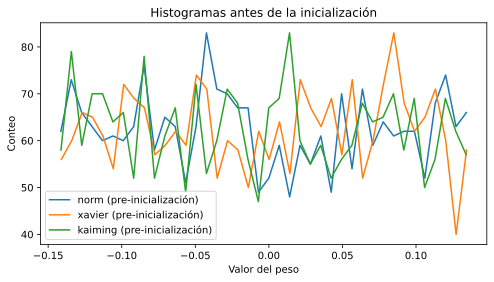

In [8]:
# Distribuciones de pesos por defecto
plt.figure(figsize=(8, 4))
for name, W in weights.items():

  # Obtener la distribución y visualizar
  y, x = np.histogram(W.weight.detach().flatten(), bins=40)
  plt.plot(x[:-1], y, label=name + ' (pre-inicialización)')

plt.legend()
plt.gca().set(
    xlabel='Valor del peso',
    ylabel='Conteo',
    title='Histogramas antes de la inicialización'
)
plt.show()

Aqui es donde inicializamos las mtrices de pesos (una std de 2 o 3 de magnitud en realidad es demasiado grande para usar en un modelo grande)

In [10]:
# Distribución normal
torch.nn.init.normal_(weights['norm'].weight, mean=0, std=3)

# Distribución de Xavier
torch.nn.init.xavier_normal_(weights['xavier'].weight) # no se le coloca nada porque esta proporcionado por el tamaño de la matrix

# Distribución de Kaiming
torch.nn.init.kaiming_uniform_(weights['kaiming'].weight);  # no se le coloca nada porque esta proporcionado por el tamaño de la matrix

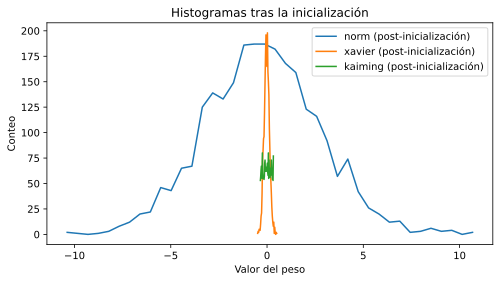

In [11]:
# Distribuciones de pesos tras la inicialización
plt.figure(figsize=(8, 4))
for name, W in weights.items():

  # Obtener la distribución y graficarla
  y, x = np.histogram(W.weight.detach().flatten(), bins=40)
  plt.plot(x[:-1], y, label=name + ' (post-inicialización)')

plt.legend()
plt.gca().set(
    xlabel='Valor del peso',
    ylabel='Conteo',
    title='Histogramas tras la inicialización'
)
plt.show()

In [14]:
# podemos observar que despues de la ditribucion kaiming es uniforme, xavier es una distribucion normal (no hay un metodo que funcione mejor)

La inicialización de pesos solo es importante para modelos muy grandes y muy profundos.